In [70]:
import re
import random
from PIL import Image
from IPython.display import display, HTML
import pandas as pd
import numpy as np 
import requests
import datetime
from bs4 import BeautifulSoup 
from tqdm import tqdm
import plotly.express as px
import plotly.graph_objects as go
from plotly.colors import sample_colorscale

In [81]:
BASE_COLS = ["team", "gf", "ga", "points"]
FOCUS_SEASON = "2025/2026"

In [104]:
random.seed(42)

In [4]:
URL_PLAYERS = "https://www.hokej.cz/tipsport-extraliga/stats-center?season=2023&competition=7071&stranger=0&stats-all=1"
URL_PLAYERS_TI = "https://www.hokej.cz/tipsport-extraliga/stats-center?season=2023&competition=7071&stranger=0&stats-section=time&stats-all=1"
URL_PLAYERS_HB = "https://www.hokej.cz/tipsport-extraliga/stats-center?season=2023&competition=7071&stranger=0&stats-section=ri&stats-all=1"

URL_TEAMS_GO = "https://www.hokej.cz/tipsport-extraliga/stats-center/team-stats"
URL_TEAMS_TI = "https://www.hokej.cz/tipsport-extraliga/stats-center/team-stats?season=2023&competition=7071&stats-section=time"
URL_TEAMS_TA = "https://www.hokej.cz/tipsport-extraliga/table"

In [5]:
r_pl = requests.get(URL_PLAYERS) 
r_pl_t = requests.get(URL_PLAYERS_TI) 
r_pl_h = requests.get(URL_PLAYERS_HB) 

r_te = requests.get(URL_TEAMS_GO) 
r_te_t = requests.get(URL_TEAMS_TI) 
r_tab = requests.get(URL_TEAMS_TA) 

In [6]:
soup_pl = BeautifulSoup(r_pl.content, 'html.parser')
soup_pl_t = BeautifulSoup(r_pl_t.content, 'html.parser')
soup_pl_h = BeautifulSoup(r_pl_h.content, 'html.parser')


soup_te = BeautifulSoup(r_te.content, 'html.parser')
soup_te_t = BeautifulSoup(r_te_t.content, 'html.parser')
soup_tab = BeautifulSoup(r_tab.content, 'html.parser')

In [7]:
table_pl = soup_pl.find("table", class_="table-stats")
table_pl_t = soup_pl_t.find("table", class_="table-stats")
table_pl_h = soup_pl_h.find("table", class_="table-stats")

table_te = soup_te.find("table", class_="table-stats")
table_te_t = soup_te_t.find("table", class_="table-stats")
table_tab = soup_tab.find("table", class_="table-soupiska")

In [8]:
teams_g = pd.read_html(str(table_te), flavor="html5lib")[0]
teams_g.columns = teams_g.columns.droplevel(0)
teams_t = pd.read_html(str(table_te_t), flavor="html5lib")[0]
teams_t.columns = teams_t.columns.droplevel(0)
teams_tab = pd.read_html(str(table_tab), flavor="html5lib")[0]
teams_tab.rename(columns={"Tým": "TÝM"}, inplace=True)

col_t_diff = [col for col in teams_t.columns if not col in teams_g.columns] + ["TÝM"]
col_tab_diff = [col for col in teams_tab.columns if not col in teams_g.columns] + ["TÝM"]

teams = teams_g.merge(teams_t[col_t_diff], on="TÝM")
teams["AVG_TOI_s"] = (
    (teams["TOI"].str.split(":", expand=True)[0].astype(int) * 60 + 
     teams["TOI"].str.split(":", expand=True)[1].astype(int)) / 
    teams["GP"]
)
teams = teams.merge(teams_tab[col_tab_diff], on="TÝM")
teams["SHOT_A"] = round(teams["Z"] * teams["SP"], 2).astype(int)

/tmp/ipykernel_29893/749331904.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  teams_g = pd.read_html(str(table_te), flavor="html5lib")[0]
/tmp/ipykernel_29893/749331904.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  teams_t = pd.read_html(str(table_te_t), flavor="html5lib")[0]
/tmp/ipykernel_29893/749331904.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  teams_tab = pd.read_html(str(table_tab), flavor="html5lib")[0]


In [9]:
players = pd.read_html(str(table_pl), flavor="html5lib")[0]
players["TOI/GP"] = pd.to_datetime(players["TOI/GP"], format="%M:%S")
players["TOI/GP_sec"] = players["TOI/GP"].dt.minute * 60 + players["TOI/GP"].dt.second

players_t = pd.read_html(str(table_pl_t), flavor="html5lib")[0]
players_t.columns = players_t.columns.droplevel(0)

players_h = pd.read_html(str(table_pl_h), flavor="html5lib")[0]

col_t_diff_t = [col for col in players_t.columns if not col in players.columns] + ["TÝM", "JMÉNO"]
col_t_diff_h = [col for col in players_h.columns if not col in players.columns] + ["TÝM", "JMÉNO"]

players = (
    players
    .merge(players_t[col_t_diff_t], on=["TÝM", "JMÉNO"])
    .merge(players_h[col_t_diff_h], on=["TÝM", "JMÉNO"])
           
)
players = players.merge(teams[["TÝM", "AVG_TOI_s"]], on="TÝM")
players["TOI_ratio"] = players["TOI/GP_sec"] / players["AVG_TOI_s"]

/tmp/ipykernel_29893/4274157785.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  players = pd.read_html(str(table_pl), flavor="html5lib")[0]
/tmp/ipykernel_29893/4274157785.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  players_t = pd.read_html(str(table_pl_t), flavor="html5lib")[0]
/tmp/ipykernel_29893/4274157785.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  players_h = pd.read_html(str(table_pl_h), flavor="html5lib")[0]


In [10]:
players.head()

,POŘ.,JMÉNO,TÝM,POZ.,GP,TOI,G,A,P,S,...,Shifts,Shifts/GP,TOI/Shift,H,AB,+,-,RI,AVG_TOI_s,TOI_ratio
0,1,Jakub Rychlovský,Bílí Tygři Liberec,Ú,51,973:44,26,20,46,133,...,1365,27,00:43,9,38,49,41,55,4842.076923,0.236675
1,2,Tomáš Filippi,Bílí Tygři Liberec,Ú,52,1065:00,25,37,62,172,...,1437,28,00:44,9,24,58,54,37,4842.076923,0.253817
2,3,Lukáš Sedlák,HC Dynamo Pardubice,Ú,44,754:23,25,22,47,119,...,1008,23,00:45,41,32,50,18,105,4748.275000,0.216710
3,4,Oliver Okuliar,Mountfield HK,Ú,52,903:17,24,21,45,198,...,1146,22,00:47,16,18,38,36,36,4916.794872,0.211927
4,5,Petr Koblasa,HC VERVA Litvínov,Ú,51,912:34,24,15,39,129,...,1192,23,00:46,10,24,34,44,24,4609.682927,0.232988


In [11]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 37 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   POŘ.        429 non-null    int64         
 1   JMÉNO       429 non-null    object        
 2   TÝM         429 non-null    object        
 3   POZ.        429 non-null    object        
 4   GP          429 non-null    int64         
 5   TOI         429 non-null    object        
 6   G           429 non-null    int64         
 7   A           429 non-null    int64         
 8   P           429 non-null    int64         
 9   S           429 non-null    int64         
 10  S%          429 non-null    float64       
 11  PPG         429 non-null    int64         
 12  PPP         429 non-null    int64         
 13  SHG         429 non-null    int64         
 14  GWG         429 non-null    int64         
 15  plus/minus  429 non-null    int64         
 16  PIM         429 non-null  

In [12]:
AB_GB = (
    players.groupby(["TÝM"], as_index=False)
    .agg(
        AB_team=("AB", "sum"),
        AB_avg_pl=("AB", "mean"),
        )
    
)

## Historické tabulky

In [13]:
seasons_links = [
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2025&matchList-filter-competition=7397",
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2024&matchList-filter-competition=7230",
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2023&matchList-filter-competition=7071",
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2022&matchList-filter-competition=6877",
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2021&matchList-filter-competition=6705", 
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2020&matchList-filter-competition=6630",
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2019&matchList-filter-competition=6475",
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2018&matchList-filter-competition=6238", 
    "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2017&matchList-filter-competition=6026",
    #"https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2016&matchList-filter-competition=5821",
    #"https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2015&matchList-filter-competition=5574",
    #"https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2014&matchList-filter-competition=3941",
    #"https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2013&matchList-filter-competition=1621",
                ]

In [14]:
def sort_table(table: pd.DataFrame) -> pd.DataFrame: 
    return (
        table[BASE_COLS]
        .assign(goal_ratio=lambda x: (x["gf"]-x["ga"])/(x["ga"] + x["gf"]))
        .sort_values(["points", "goal_ratio", "gf", "team"], ascending=[False, False, False, True])
        .drop(columns=["goal_ratio"])
        .reset_index(drop=True)
        .reset_index(drop=False, names="rank")
        .assign(rank=lambda x: x["rank"]+1)
    )

In [15]:
def extract_round_results(table_round: str) -> [pd.DataFrame, str]: 
    round_results = []
    delayed_matches = ""
    for tr in table_round.find_all("tr", class_="js-preview__link"):
        team_h, team_a = [span.text.strip() for span in tr.find_all("span", class_="preview__name--short")]
        try:
            gf = int(tr.find("td", class_="preview__score").text.strip())
            ga = int(tr.find("td", class_="preview__score preview__score--right").text.strip())
            preview_dot = tr.find("div", class_="preview__dot")
            preview_dot_text = (
                preview_dot.find("span", class_="dot__blue").text.strip() 
                if preview_dot and preview_dot.find("span", class_="dot__blue") else None
                               )
            ot = bool(preview_dot_text) & abs(gf-ga)==1 
            points_h = abs((gf > ga) * 3 - ot)
    
            round_results.append([team_h, gf, ga, points_h])
            round_results.append([team_a, ga, gf, 3-points_h])
        except: 
            delayed_matches += f" {team_h}vs.{team_a} "
        
    return pd.DataFrame(round_results, columns=BASE_COLS), delayed_matches

In [16]:
def extract_season_results(table_season: str, season_name: str) -> pd.DataFrame: 
    cumulative_table = pd.DataFrame(columns=BASE_COLS)
    complete_table = []
    round_nr = 0 
    for table_round in table_season: 
        round_nr += 1
        actual_table, delayed_matches = extract_round_results(table_round)
        if actual_table.shape[0] >= 4:
            if len(delayed_matches)>0: 
                print(f"zápasy {round_nr}. kola {season_name} {delayed_matches} nehrány - kolo počítáno")
            cumulative_table = (
                sort_table(
                    pd.concat([cumulative_table[BASE_COLS], actual_table])
                    .groupby('team', as_index=False).sum()
                )
                               )
            complete_table.append(
                cumulative_table
                .assign(
                    round=round_nr, 
                    season=season_name, 
                )
            )
        else: 
            print(f"zápasy {round_nr}. kola {season_name} {delayed_matches} nehrány")
            
    return pd.concat(complete_table, ignore_index=True)

In [17]:
def extract_tables(links) -> pd.DataFrame: 
    complete_tables = []
    for url_link in tqdm(links): 
        season_y = int(re.search(r'season=(\d+)', url_link).group(1))
        season_name = str(season_y) + "/" + str(season_y+1)
        r = requests.get(url_link)
        bs = BeautifulSoup(r.content, 'html.parser')
        table = bs.find_all("table", class_="preview")
        complete_tables.append(extract_season_results(table, season_name))
        
    return pd.concat(complete_tables, ignore_index=True)

In [18]:
%%time
tables_df = extract_tables(seasons_links)

 11%|█████                                        | 1/9 [00:00<00:07,  1.10it/s]

zápasy 21. kola 2025/2026  KVAvs.LIB  nehrány - kolo počítáno
zápasy 22. kola 2025/2026  PCEvs.KOM  nehrány - kolo počítáno
zápasy 34. kola 2025/2026  MBLvs.SPA  nehrány - kolo počítáno
zápasy 36. kola 2025/2026  PLZvs.SPA  nehrány - kolo počítáno
zápasy 37. kola 2025/2026  SPAvs.MHK  nehrány - kolo počítáno
zápasy 39. kola 2025/2026  MBLvs.MHK  LIBvs.CEB  nehrány - kolo počítáno
zápasy 40. kola 2025/2026  SPAvs.CEB  nehrány - kolo počítáno
zápasy 41. kola 2025/2026  PLZvs.OLO  nehrány - kolo počítáno
zápasy 42. kola 2025/2026  SPAvs.KOM  CEBvs.PLZ  MBLvs.PCE  VITvs.LIT  LIBvs.TRI  MHKvs.KLA  OLOvs.KVA  nehrány
zápasy 43. kola 2025/2026  VITvs.KOM  KLAvs.OLO  LIBvs.LIT  KVAvs.SPA  PLZvs.MHK  MBLvs.TRI  PCEvs.CEB  nehrány
zápasy 44. kola 2025/2026  SPAvs.LIT  PLZvs.TRI  MBLvs.VIT  CEBvs.KLA  OLOvs.PCE  MHKvs.KVA  LIBvs.KOM  nehrány
zápasy 45. kola 2025/2026  TRIvs.CEB  LITvs.OLO  KVAvs.MBL  KLAvs.LIB  PCEvs.PLZ  KOMvs.MHK  nehrány
zápasy 46. kola 2025/2026  SPAvs.OLO  PLZvs.KOM  CEBvs.K

100%|█████████████████████████████████████████████| 9/9 [00:07<00:00,  1.19it/s]

CPU times: user 4.07 s, sys: 44.7 ms, total: 4.12 s
Wall time: 7.57 s


In [19]:
tables_df["team"].value_counts()

team
PCE    465
LIB    465
PLZ    465
KOM    465
MBL    465
VIT    465
MHK    465
TRI    465
LIT    465
OLO    465
SPA    464
KVA    413
KLA    309
CEB    309
ZLN    268
CHM    104
JIH     52
Name: count, dtype: int64

In [20]:
tables_KVA = (
    tables_df
    .loc[lambda x: x["team"]=="KVA"]
    .loc[lambda x: x["round"]<=52]
    [["round", "rank", "points", "season"]]
    .reset_index(drop=True)
             )

In [21]:
tables_KVA.tail()

,round,rank,points,season
400,48,12,47,2018/2019
401,49,12,48,2018/2019
402,50,12,50,2018/2019
403,51,12,53,2018/2019
404,52,12,53,2018/2019


In [74]:
def define_color_map(
    df,
    sort_by,
    exclude,
    target_rgb=(59, 172, 170),
    min_pos=0.45, 
    max_pos=0.9,
    opacity=0.8,
):
    season_list = (
        df.loc[~df["season"].isin(exclude)]
        .groupby("season", as_index=False)
        .agg(top_score=(sort_by, "max"))
        .sort_values("top_score", ascending=True)
        ["season"]
        .tolist()
    )

    n = len(season_list)
    positions = [
        min_pos + i * (max_pos - min_pos) / max(n - 1, 1)
        for i in range(n)
    ]

    base_colors = sample_colorscale("Blues", positions)

    def mix_with_target(rgb_str, target, alpha=0.4):
        r, g, b = map(int, rgb_str[4:-1].split(","))
        tr, tg, tb = target
        r = int((1 - alpha) * r + alpha * tr)
        g = int((1 - alpha) * g + alpha * tg)
        b = int((1 - alpha) * b + alpha * tb)
        return f"rgba({r},{g},{b},{opacity})"

    return {
        season: mix_with_target(color, target_rgb)
        for season, color in zip(season_list, base_colors)
    }


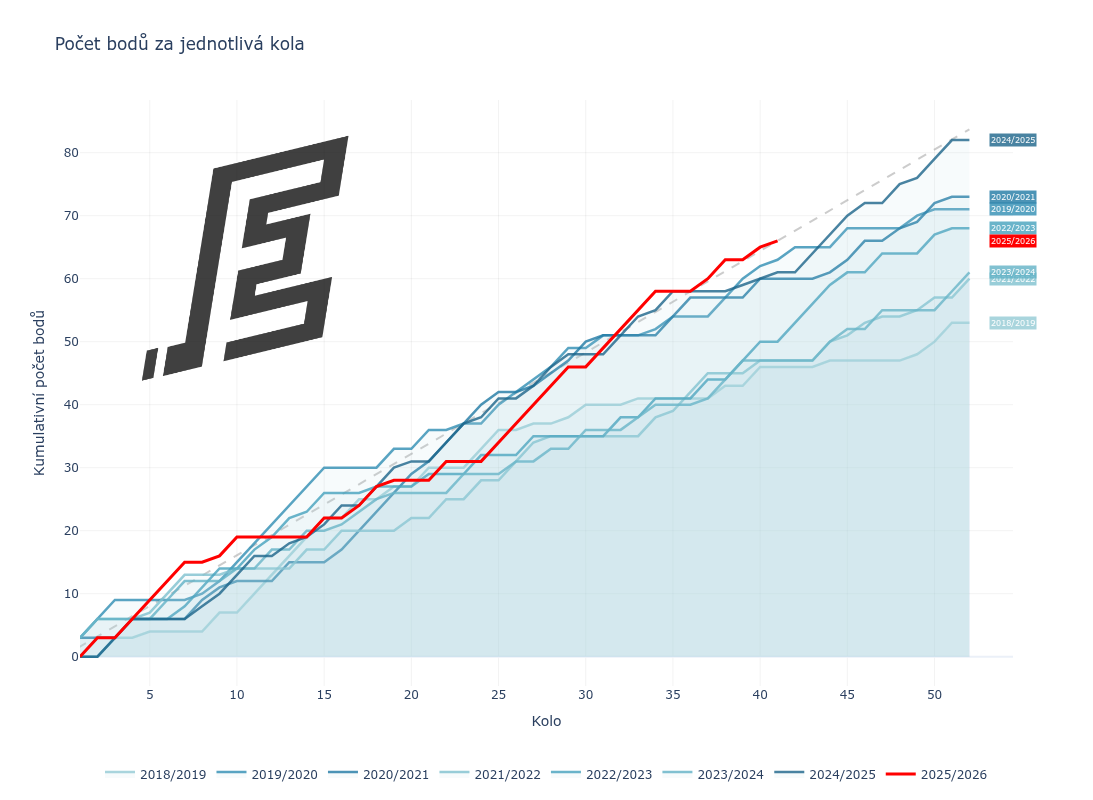

In [82]:
fig = go.Figure() 

max_round = max(tables_KVA["round"])
max_points = (
    tables_KVA
        .loc[lambda x: x["season"] == FOCUS_SEASON]
        [["points", "round"]]
        .max()
        .pipe(lambda s: s["points"] / s["round"]) * max_round
            )
fig.add_trace(go.Scatter(
    x=[0, max_round],
    y=[0, max_points],
    mode="lines",
    line=dict(color="rgba(128, 128, 128, 0.4)", dash="dash"),
    showlegend=False
))

hover_temp = "<br><b>%{text}</b>. v tabulce<br>" + "%{y} bodů<br>"

color_map = define_color_map(df=tables_KVA, sort_by="points", exclude=[FOCUS_SEASON], min_pos=0.2, max_pos=0.98)
a = 0
for season_name, season_df in tables_KVA.groupby("season"): 
    if season_name in [FOCUS_SEASON]: 
        continue
    a += 25
    fig.add_trace(go.Scatter(
        x=season_df["round"],
        y=season_df["points"],
        fill="tozeroy",
        fillcolor="rgba(173, 216, 230, 0.1)",
        line=dict(color=color_map[season_name], width=2.5),
        mode="lines",
        name=season_name, 
        text=season_df["rank"],
        hovertemplate=hover_temp,
    ))
    max_points_season = season_df["points"].max()
    fig.add_annotation(
        x=max_round+2.5, 
        y=max_points_season,
        xref="x", yref="y",
        text=season_name,
        showarrow=False,
        ax=20,
        ay=-40, 
        bgcolor=color_map[season_name],
        font=dict(color="white", size=8,),
    )
    

season_data = tables_KVA.loc[lambda x: x["season"] == FOCUS_SEASON]
fig.add_trace(go.Scatter(
    x=season_data["round"],
    y=season_data["points"],
    mode="lines",
    line=dict(color="red", width=3),
    name=FOCUS_SEASON, 
    text=season_df["rank"],
    hovertemplate=hover_temp,
))
fig.add_annotation(
    x=max_round+2.5, 
    y=season_data["points"].max(),
    xref="x", yref="y",
    text=FOCUS_SEASON,
    showarrow=False,
    ax=20,
    ay=-40, 
    bgcolor="red",
    font=dict(color="white", size=8,),
)


img = Image.open("logo.png")
fig.add_layout_image(
    dict(
        source=img,
        xref="paper", yref="paper",
        x=0.02, y=0.98,
        sizex=0.5, sizey=0.5,
        xanchor="left",
        yanchor="top",
        opacity=0.75
    )
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Kolo",
    yaxis_title="Kumulativní počet bodů",
    title="Počet bodů za jednotlivá kola",
    height=800,
    legend=dict(
        x=0.5,
        y=-0.15,
        orientation="h",
        traceorder="normal",
        xanchor="center",  
        yanchor="middle" 
    ),
    hovermode='x unified',
)
fig.update_xaxes(dtick=5, tickmode="linear", range=[1, max_round+2.5], gridcolor="rgba(0,0,0,0.05)")
fig.update_yaxes(showgrid=True, gridcolor="rgba(0,0,0,0.05)")

fig.show()

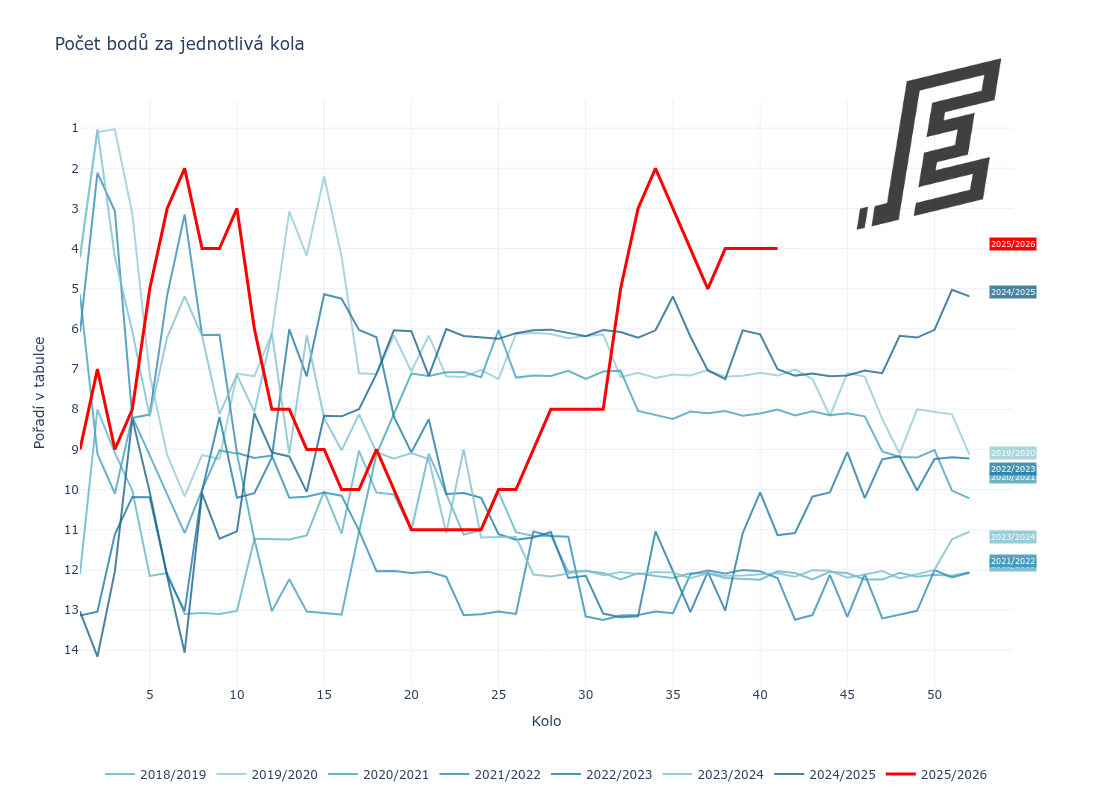

In [111]:
fig = go.Figure() 

max_round = max(tables_KVA["round"])
max_points = max(tables_KVA["points"])

hover_temp = "<br><b>%{y:.0f}</b>. v tabulce<br>" + "%{text} bodů<br>"

color_map = define_color_map(df=tables_KVA, sort_by="rank", exclude=[FOCUS_SEASON], min_pos=0.2, max_pos=0.98)
a = 0
for season_name, season_df in tables_KVA.groupby("season"): 
    if season_name in [FOCUS_SEASON]: 
        continue
    a += 25
    fig.add_trace(go.Scatter(
        x=season_df["round"],
        y=season_df["rank"].apply(lambda x: x+random.uniform(0, .25)),
        line=dict(color=color_map[season_name], width=2),
        mode="lines",
        name=season_name, 
        text=season_df["points"],
        hovertemplate=hover_temp,
    ))
    final_posotion_season = season_df.loc[lambda x: x["round"]==season_df["round"].max(), "rank"].max() + random.uniform(-0.5, 0.5)
    fig.add_annotation(
        x=max_round+2.5, 
        y=final_posotion_season,
        xref="x", yref="y",
        text=season_name,
        showarrow=False,
        ax=20,
        ay=-40, 
        bgcolor=color_map[season_name],
        font=dict(color="white", size=8),
    )
    

season_data = tables_KVA.loc[lambda x: x["season"] == FOCUS_SEASON]
final_posotion_season = season_data.loc[lambda x: x["round"]==season_df["round"].max(), "rank"].max() + random.uniform(-0.5, 0.5)
fig.add_trace(go.Scatter(
    x=season_data["round"],
    y=season_data["rank"],
    mode="lines",
    line=dict(color="red", width=3),
    name=FOCUS_SEASON, 
    text=season_df["rank"],
    hovertemplate=hover_temp,
))
fig.add_annotation(
    x=max_round+2.5, 
    y=final_posotion_season,
    xref="x", yref="y",
    text=FOCUS_SEASON,
    showarrow=False,
    ax=20,
    ay=-40, 
    bgcolor="red",
    font=dict(color="white", size=8),
)


img = Image.open("logo.png")
fig.add_layout_image(
    dict(
        source=img,
        xref="paper", yref="paper",
        x=0.8, y=1.1,
        sizex=0.35, sizey=0.35,
        xanchor="left",
        yanchor="top",
        opacity=0.75
    )
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Kolo",
    yaxis_title="Pořadí v tabulce",
    title="Počet bodů za jednotlivá kola",
    height=800,
    legend=dict(
        x=0.5,
        y=-0.15,
        orientation="h",
        traceorder="normal",
        xanchor="center",  
        yanchor="middle" 
    ),
    hovermode='x unified',
    yaxis=dict(autorange="reversed")
)
fig.update_xaxes(dtick=5, tickmode="linear", range=[1, max_round+2.5])
fig.update_yaxes(dtick=1, )

fig.show()

In [27]:
tables_KVA.loc[lambda x: x["round"]]

,round,rank,points,season
1,2,7,3,2025/2026
2,3,9,3,2025/2026
3,4,8,6,2025/2026
4,5,5,9,2025/2026
5,6,3,12,2025/2026
...,...,...,...,...
48,8,10,8,2024/2025
49,9,11,10,2024/2025
50,10,11,13,2024/2025
51,11,8,16,2024/2025


In [28]:
logo_link = "https://www.hokej.cz/files/logos/rqvj5-kva.png"